### Лабораторная работа 5: PageRank

In [1]:
# %pip install -q python-graphblas scipy pandas matplotlib psutil networkx

In [2]:
import os
import time
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import scipy.sparse as sp

import networkx as nx

In [3]:
import graphblas as gb

gb.init("suitesparse", blocking=False)

from graphblas import Matrix, dtypes, monoid, agg, Vector, binary, semiring
from graphblas import semiring, binary, unary, monoid, op, replace
from graphblas.io import mmread

In [4]:
plt.style.use("default")
np.random.seed(0)

print("graphblas:", gb.__version__)

graphblas: 2024.2.0


---

### PageRank на graphblas

In [ ]:
def pagerank_graphblas(A, damping=0.85, max_iter=100, tol=1e-6, dtype=dtypes.FP32):
    n = A.nrows
    np_dtype = np.float32 if dtype == dtypes.FP32 else np.float64

    A_num = A.dup(dtype=dtype)

    out_degree = A_num.reduce_rowwise(monoid.plus).new()
    out_degree_np = out_degree.to_dense(fill_value=0.0)

    active = np.where(out_degree_np > 0)[0]
    inv_out = Vector(dtype, n)
    if len(active) > 0:
        inv_out = Vector.from_coo(
            active,
            (1.0 / out_degree_np[active]).astype(np_dtype),
            size=n,
            dtype=dtype,
        )

    dangling_ids = np.where(out_degree_np == 0)[0]
    dangling = Vector(dtype, n)
    if len(dangling_ids) > 0:
        dangling = Vector.from_coo(
            dangling_ids,
            np.ones(len(dangling_ids), dtype=np_dtype),
            size=n,
            dtype=dtype,
        )

    rank = Vector.from_dense(np.full(n, 1.0 / n, dtype=np_dtype), dtype=dtype)
    history = []

    for _ in range(max_iter):
        old = rank.dup()

        scaled = old.ewise_mult(inv_out, binary.times).new()
        walk = A_num.T.mxv(scaled, semiring.plus_times).new()

        new_rank = walk.dup()
        new_rank << binary.times(damping, new_rank)

        add = (1.0 - damping) / n
        if dangling.nvals > 0:
            dangling_mass = old.inner(dangling, semiring.plus_times).new().value
            add += damping * float(dangling_mass or 0.0) / n

        new_rank(binary.plus)[:] << add

        diff = (
            new_rank.ewise_add(old, binary.minus)
            .apply(gb.unary.abs)
            .reduce(monoid.plus)
            .new()
            .value
        )
        diff = float(diff or 0.0)
        history.append(diff)

        rank << new_rank
        if diff < tol:
            break

    total = rank.reduce(monoid.plus).new().value
    rank << binary.truediv(rank, total)

    return rank, history


def pagerank_scipy_base(A, damping=0.85, max_iter=100, tol=1e-6):
    n = A.shape[0]

    out_degree = np.asarray(A.sum(axis=1)).ravel()
    active = out_degree > 0

    inv_out = np.zeros(n, dtype=np.float64)
    inv_out[active] = 1.0 / out_degree[active]

    M = sp.diags(inv_out) @ A

    rank = np.ones(n, dtype=np.float64) / n
    history = []

    for _ in range(max_iter):
        old = rank.copy()

        walk = M.T @ old
        add = (1.0 - damping) / n + damping * old[~active].sum() / n
        rank = damping * walk + add

        diff = np.abs(rank - old).sum()
        history.append(float(diff))
        if diff < tol:
            break

    rank = rank / rank.sum()
    return rank, history


def vector_to_numpy(v):
    return v.to_dense(fill_value=0.0)


def measure_time_memory(func, *args, **kwargs):
    proc = psutil.Process(os.getpid())
    start_mem = proc.memory_info().rss
    peak_mem = start_mem
    stop = False

    def watcher():
        nonlocal peak_mem
        while not stop:
            peak_mem = max(peak_mem, proc.memory_info().rss)
            time.sleep(0.01)

    thread = threading.Thread(target=watcher, daemon=True)
    thread.start()

    t0 = time.perf_counter()
    try:
        result = func(*args, **kwargs)
    finally:
        dt = time.perf_counter() - t0
        stop = True
        thread.join()

    extra_mb = (peak_mem - start_mem) / (1024 ** 2)
    return result, dt, extra_mb

### Тесты и примеры

In [6]:
rows = np.array([0, 0, 1, 2, 2, 3], dtype=np.int64)
cols = np.array([1, 2, 2, 0, 3, 0], dtype=np.int64)

A_small_gb = Matrix.from_coo(
    rows,
    cols,
    np.ones(len(rows), dtype=bool),
    nrows=4,
    ncols=4,
    dtype=dtypes.BOOL,
    dup_op=binary.lor,
)
A_small_csr = sp.csr_matrix(
    (np.ones(len(rows), dtype=np.float32), (rows, cols)),
    shape=(4, 4),
    dtype=np.float32,
)

r_gb_small, _ = pagerank_graphblas(A_small_gb, dtype=dtypes.FP64, tol=1e-8)
r_sp_small, _ = pagerank_scipy_base(A_small_csr, tol=1e-8)

assert np.allclose(vector_to_numpy(r_gb_small), r_sp_small, atol=1e-8)

print("Все тесты пройдены!")
print(vector_to_numpy(r_gb_small))

Все тесты пройдены!
[0.3245614 0.1754386 0.3245614 0.1754386]


### Инкрементальный PageRank (с дополнительными настройками)

In [7]:
def add_edges_graphblas(A, new_edges):
    B = A.dup()
    for u, v in new_edges:
        B[u, v] = True
    return B


def row_columns(A, row):
    idx, _ = A[row, :].new().to_coo()
    return set(idx.tolist())


def build_delta_transition(A_old, A_new, changed_rows, dtype=dtypes.FP32):
    n = A_old.nrows

    A_old_num = A_old.dup(dtype=dtype)
    A_new_num = A_new.dup(dtype=dtype)

    deg_old = A_old_num.reduce_rowwise(monoid.plus).new().to_dense(fill_value=0.0)
    deg_new = A_new_num.reduce_rowwise(monoid.plus).new().to_dense(fill_value=0.0)

    rows = []
    cols = []
    vals = []

    for u in changed_rows:
        old_cols = row_columns(A_old, u)
        new_cols = row_columns(A_new, u)

        for v in sorted(old_cols | new_cols):
            old_value = 0.0
            if deg_old[u] > 0 and v in old_cols:
                old_value = 1.0 / deg_old[u]

            new_value = 0.0
            if deg_new[u] > 0 and v in new_cols:
                new_value = 1.0 / deg_new[u]

            delta = new_value - old_value
            if delta != 0:
                rows.append(u)
                cols.append(v)
                vals.append(delta)

    if len(rows) == 0:
        return Matrix(dtype, n, n)

    return Matrix.from_coo(
        rows,
        cols,
        vals,
        nrows=n,
        ncols=n,
        dtype=dtype,
        dup_op=binary.plus,
    )


def incremental_pagerank(A_old, r_old, new_edges, damping=0.85, max_iter=20, tol=1e-7, dtype=dtypes.FP32):
    n = A_old.nrows
    np_dtype = np.float32 if dtype == dtypes.FP32 else np.float64

    changed_rows = sorted({int(u) for u, _ in new_edges})
    A_new = add_edges_graphblas(A_old, new_edges)

    A_new_num = A_new.dup(dtype=dtype)
    deg_new = A_new_num.reduce_rowwise(monoid.plus).new()
    deg_new_np = deg_new.to_dense(fill_value=0.0)

    active = np.where(deg_new_np > 0)[0]
    inv_out = Vector(dtype, n)
    if len(active) > 0:
        inv_out = Vector.from_coo(
            active,
            (1.0 / deg_new_np[active]).astype(np_dtype),
            size=n,
            dtype=dtype,
        )

    dangling_ids = np.where(deg_new_np == 0)[0]
    dangling = Vector(dtype, n)
    if len(dangling_ids) > 0:
        dangling = Vector.from_coo(
            dangling_ids,
            np.ones(len(dangling_ids), dtype=np_dtype),
            size=n,
            dtype=dtype,
        )

    delta_M = build_delta_transition(A_old, A_new, changed_rows, dtype=dtype)

    base = delta_M.T.mxv(r_old, semiring.plus_times).new()
    base << binary.times(damping, base)

    delta = base.dup()

    for iteration in range(max_iter):
        old_delta = delta.dup()

        scaled = old_delta.ewise_mult(inv_out, binary.times).new()
        step = A_new_num.T.mxv(scaled, semiring.plus_times).new()
        step << binary.times(damping, step)

        if dangling.nvals > 0:
            dangling_mass = old_delta.inner(dangling, semiring.plus_times).new().value
            step(binary.plus)[:] << damping * float(dangling_mass or 0.0) / n

        new_delta = base.dup()
        new_delta(binary.plus) << step

        diff = (
            new_delta.ewise_add(old_delta, binary.minus)
            .apply(gb.unary.abs)
            .reduce(monoid.plus)
            .new()
            .value
        )
        diff = float(diff or 0.0)

        delta << new_delta
        if diff < tol:
            break

    r_new_np = vector_to_numpy(r_old) + vector_to_numpy(delta)
    r_new_np = np.maximum(r_new_np, 0.0)
    r_new_np = r_new_np / r_new_np.sum()

    r_new = Vector.from_dense(r_new_np.astype(np_dtype), dtype=dtype)
    info = {"iterations": iteration + 1, "changed_rows": len(changed_rows)}
    return r_new, A_new, info


def random_new_edges(A_csr, count=100, seed=1):
    rng = np.random.default_rng(seed)
    n = A_csr.shape[0]
    out_degree = np.asarray(A_csr.sum(axis=1)).ravel()
    good_rows = np.where(out_degree > 0)[0]

    edges = []
    used = set()
    while len(edges) < count:
        u = int(rng.choice(good_rows))
        v = int(rng.integers(0, n))

        if u == v or (u, v) in used:
            continue
        if A_csr[u, v] != 0:
            continue

        edges.append((u, v))
        used.add((u, v))

    return edges

### Тесты и примеры

In [8]:
rows = np.array([0, 0, 1, 2, 2, 3], dtype=np.int64)
cols = np.array([1, 2, 2, 0, 3, 0], dtype=np.int64)

A_small = Matrix.from_coo(
    rows, cols,
    np.ones(len(rows), dtype=bool),
    nrows=4, ncols=4,
    dtype=dtypes.BOOL,
    dup_op=binary.lor,
)

r_old, _ = pagerank_graphblas(A_small, dtype=dtypes.FP64, tol=1e-8)

new_edges = [(1, 0), (3, 2)]

r_inc, _, inc_info = incremental_pagerank(
    A_small, r_old, new_edges,
    damping=0.85, max_iter=20, tol=1e-8, dtype=dtypes.FP64
)

A_new = add_edges_graphblas(A_small, new_edges)
r_full, _ = pagerank_graphblas(A_new, dtype=dtypes.FP64, tol=1e-8)

diff = np.max(np.abs(vector_to_numpy(r_inc) - vector_to_numpy(r_full)))
print(f"max diff inc vs full: {diff:.2e}")

max diff inc vs full: 0.00e+00


---

### Эксперимент

Граф `wb-cs-stanford` брался с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/). Сравнение проводилось с [реализацией из библиотеки NetworkX](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html):
- PageRank на исходном графе;
- инкрементальный PageRank после добавления новых ребер.

In [9]:
mtx_path = "../data/wb-cs-stanford/wb-cs-stanford.mtx"
A_coo = mmread(mtx_path).to_coo()
rows = A_coo[0].astype(np.int64)
cols = A_coo[1].astype(np.int64)
vals = np.ones(len(rows), dtype=bool)

A_gb = Matrix.from_coo(
    rows, cols, vals,
    nrows=A_coo[0].shape[0], ncols=A_coo[1].shape[0],
    dtype=dtypes.BOOL, dup_op=binary.lor
)

A_csr = sp.csr_matrix((np.ones(len(rows), dtype=np.float32), (rows, cols)),
                      shape=(A_coo[0].shape[0], A_coo[1].shape[0]), dtype=np.float32)
A_csr.sum_duplicates()
A_csr.data[:] = 1.0
A_csr.sort_indices()

print(f"vertices: {A_gb.nrows}, edges: {A_gb.nvals}")

damping = 0.85
tol = 1e-6
max_iter = 100

(r_gb, hist_gb), t_gb, mem_gb = measure_time_memory(
    pagerank_graphblas, A_gb, damping, max_iter, tol, dtypes.FP32
)
r_gb_np = vector_to_numpy(r_gb)

(r_gb64, hist_gb64), t_gb64, mem_gb64 = measure_time_memory(
    pagerank_graphblas, A_gb, damping, max_iter, tol, dtypes.FP64
)
r_gb64_np = vector_to_numpy(r_gb64)

edges = list(zip(rows, cols))
G = nx.DiGraph()
G.add_edges_from(edges)
G.add_nodes_from(range(A_gb.nrows))

t0 = time.perf_counter()
proc = psutil.Process(os.getpid())
start_mem = proc.memory_info().rss
r_nx = nx.pagerank(G, alpha=damping, tol=tol, max_iter=max_iter)
t_nx = time.perf_counter() - t0
mem_nx = (proc.memory_info().rss - start_mem) / (1024**2)

r_nx_np = np.array([r_nx[i] for i in range(A_gb.nrows)])

diff_gb = np.max(np.abs(r_gb_np - r_gb64_np))
diff_nx = np.max(np.abs(r_nx_np - r_gb64_np))

results = pd.DataFrame([
    ["graphblas fp32", len(hist_gb), t_gb, mem_gb],
    ["graphblas fp64", len(hist_gb64), t_gb64, mem_gb64],
    ["networkx", np.nan, t_nx, mem_nx]
], columns=["version", "iterations", "time_sec", "extra_peak_mb"])
display(results)
print(f"diff fp32 vs fp64: {diff_gb:.2e}")
print(f"diff networkx vs fp64: {diff_nx:.2e}")

top_idx = np.argsort(r_gb64_np)[-10:][::-1]
print("top 10 vertices (graphblas fp64):")
for i, idx in enumerate(top_idx, 1):
    print(f"{i}: {idx}  {r_gb64_np[idx]:.6f}")

vertices: 36854, edges: 36854


,version,iterations,time_sec,extra_peak_mb
0,graphblas fp32,57.0,0.156185,20.984375
1,graphblas fp64,55.0,0.253452,23.816406
2,networkx,NaN,0.127055,7.054688


diff fp32 vs fp64: 3.97e-08
diff networkx vs fp64: 5.51e-04
top 10 vertices (graphblas fp64):
1: 2263  0.004517
2: 8225  0.003982
3: 8058  0.003302
4: 8056  0.002861
5: 4484  0.002746
6: 5706  0.002560
7: 8224  0.002516
8: 6838  0.002482
9: 6839  0.002482
10: 6836  0.002482


---

In [10]:
try:
    A_gb
except NameError:
    mtx_path = "../data/wb-cs-stanford/wb-cs-stanford.mtx"
    A_csr = mmread(mtx_path).tocsr().astype(np.float32)
    A_csr.data[:] = 1.0
    A_csr.sum_duplicates()
    A_csr.sort_indices()
    A_gb = Matrix.from_scipy_sparse(A_csr, dtype=dtypes.BOOL, dup_op=binary.lor)

try:
    r_base
except NameError:
    r_base, _ = pagerank_graphblas(A_gb, damping=0.85, max_iter=100, tol=1e-6, dtype=dtypes.FP32)

edge_counts = [10, 20, 50, 70, 100, 200, 500]
results_inc = []

for n_edges in edge_counts:
    new_edges = random_new_edges(A_csr, count=n_edges, seed=42 + n_edges)
    print(f"\nДобавление {n_edges} рёбер...")

    (r_inc, A_new, inc_info), t_inc, mem_inc = measure_time_memory(
        incremental_pagerank,
        A_gb, r_base, new_edges,
        damping=0.85, max_iter=30, tol=1e-7, dtype=dtypes.FP32
    )

    (r_full, hist_full), t_full, mem_full = measure_time_memory(
        pagerank_graphblas,
        A_new, 0.85, 100, 1e-6, dtypes.FP32
    )

    max_diff = np.max(np.abs(vector_to_numpy(r_inc) - vector_to_numpy(r_full)))

    results_inc.append({
        "added_edges": n_edges,
        "inc_iter": inc_info["iterations"],
        "inc_time": t_inc,
        "inc_mem_mb": mem_inc,
        "full_iter": len(hist_full),
        "full_time": t_full,
        "full_mem_mb": mem_full,
        "max_abs_diff": max_diff
    })


Добавление 10 рёбер...

Добавление 20 рёбер...

Добавление 50 рёбер...

Добавление 70 рёбер...

Добавление 100 рёбер...

Добавление 200 рёбер...

Добавление 500 рёбер...



Сравнение инкрементального и полного пересчёта:


,added_edges,inc_iter,inc_time,inc_mem_mb,full_iter,full_time,full_mem_mb,max_abs_diff
0,10,30,0.129179,15.957031,56,0.150889,3.484375,1.353910e-07
1,20,30,0.209477,15.792969,58,0.167870,2.460938,3.020978e-07
2,50,30,0.118751,4.718750,57,0.107134,5.804688,3.906025e-07
3,70,30,0.121407,13.957031,57,0.108160,9.808594,3.559398e-07
4,100,30,0.103682,19.050781,57,0.097534,2.789062,7.132767e-07
5,200,30,0.148254,5.667969,58,0.107726,6.097656,2.349261e-06
6,500,30,0.241319,19.656250,57,0.090991,10.531250,5.840557e-07


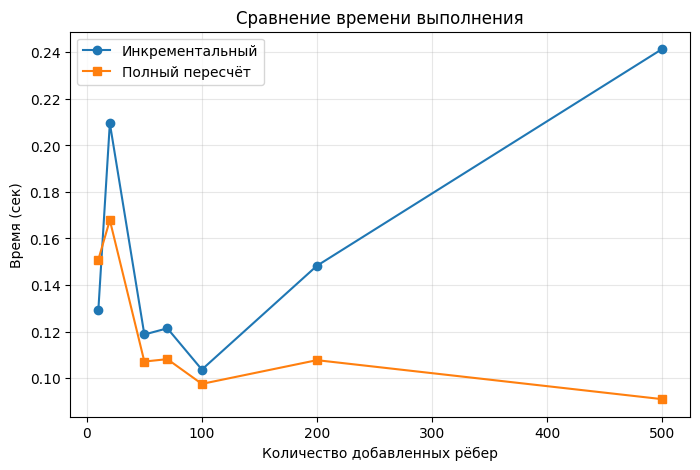

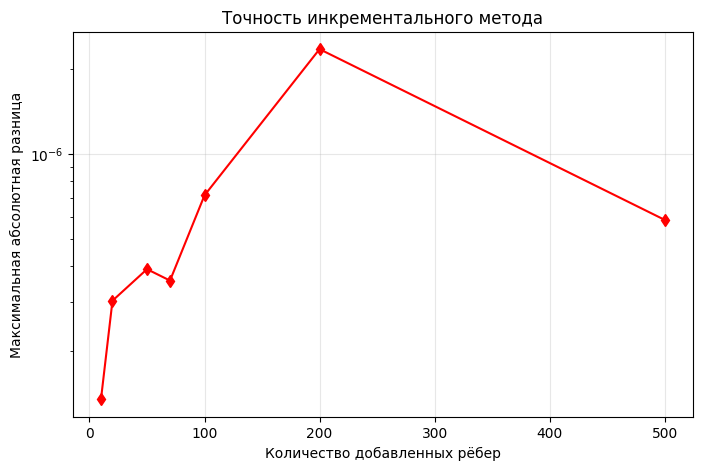

In [11]:
df_inc = pd.DataFrame(results_inc)
print("\nСравнение инкрементального и полного пересчёта:")
display(df_inc)

plt.figure(figsize=(8,5))
plt.plot(df_inc["added_edges"], df_inc["inc_time"], 'o-', label="Инкрементальный")
plt.plot(df_inc["added_edges"], df_inc["full_time"], 's-', label="Полный пересчёт")
plt.xlabel("Количество добавленных рёбер")
plt.ylabel("Время (сек)")
plt.title("Сравнение времени выполнения")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(df_inc["added_edges"], df_inc["max_abs_diff"], 'd-', color='red')
plt.yscale('log')
plt.xlabel("Количество добавленных рёбер")
plt.ylabel("Максимальная абсолютная разница")
plt.title("Точность инкрементального метода")
plt.grid(True, alpha=0.3)
plt.show()

Выводы:
- из сравнения скорости работы реализованных методов относительно библитеочной реализации видим, что  `graphblas` существенно не отстаёт от `NetworkX` как по точности, так и по вермени выполнения (в случае использования `fp32`)
- из сравнения базового и инкрментального PageRank видно, что дополнения ускоряют улучшают работу модели, в разреженных графах (когда мало добавленных рёбер)

Было показано, что реализованные методы корректно работают, как на сгенерированных случайных графах, так и на реальных (с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/))